# 2. LightGBM

In [1]:
import pandas as pd
import numpy as np

X_train = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/X_train.parquet"
)

X_test = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/X_test.parquet"
)

y_train = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/y_train.parquet"
)["Label"]

y_test = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/y_test.parquet"
)["Label"]

label_mapping = pd.read_csv(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/label_mapping.csv"
)

class_names = label_mapping["class_name"].values

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1785379, 77)
(446345, 77)
(1785379,)
(446345,)


In [2]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm.fit(X_train, y_train)

LGBMClassifier(learning_rate=0.05, n_estimators=300, n_jobs=-1, random_state=42,
               verbosity=-1)

In [3]:
import joblib

joblib.dump(
    lgbm,
    "/kaggle/working/lgbm_model.pkl"
)

print("LightGBM model saved.")

LightGBM model saved.


In [4]:
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_lgbm)

precision_weighted = precision_score(
    y_test, y_pred_lgbm,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test, y_pred_lgbm,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_test, y_pred_lgbm,
    average="weighted",
    zero_division=0
)

precision_macro = precision_score(
    y_test, y_pred_lgbm,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test, y_pred_lgbm,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test, y_pred_lgbm,
    average="macro",
    zero_division=0
)

mcc = matthews_corrcoef(y_test, y_pred_lgbm)

from sklearn.preprocessing import label_binarize

classes = np.arange(len(class_names))

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

auc = roc_auc_score(
    y_test_bin,
    y_prob_lgbm,
    multi_class="ovr",
    average="weighted"
)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Weighted Precision : {precision_weighted:.4f}")
print(f"Weighted Recall    : {recall_weighted:.4f}")
print(f"Weighted F1        : {f1_weighted:.4f}")
print(f"Macro Precision    : {precision_macro:.4f}")
print(f"Macro Recall       : {recall_macro:.4f}")
print(f"Macro F1           : {f1_macro:.4f}")
print(f"MCC                : {mcc:.4f}")
print(f"AUC                : {auc:.4f}")

Accuracy           : 0.9532
Weighted Precision : 0.9586
Weighted Recall    : 0.9532
Weighted F1        : 0.9555
Macro Precision    : 0.2628
Macro Recall       : 0.2757
Macro F1           : 0.2673
MCC                : 0.8262
AUC                : 0.9363


In [6]:
print(
    classification_report(
        y_test,
        y_pred_lgbm,
        labels=classes,
        target_names=class_names,
        zero_division=0
    )
)

                            precision    recall  f1-score   support

                    Benign       0.98      0.98      0.98    379047
                       Bot       0.00      0.00      0.00       288
                      DDoS       0.88      0.75      0.80     25603
             DoS GoldenEye       0.22      0.22      0.22      2057
                  DoS Hulk       0.90      0.91      0.90     34569
          DoS Slowhttptest       0.00      0.00      0.00      1046
             DoS slowloris       0.43      0.61      0.50      1077
               FTP-Patator       0.53      0.67      0.59      1186
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.00      0.00      0.00       391
               SSH-Patator       0.00      0.00      0.00       644
  Web Attack � Brute Force       0.00      0.00      0.00       294
Web Attack � Sql Injection       0.00      0.00

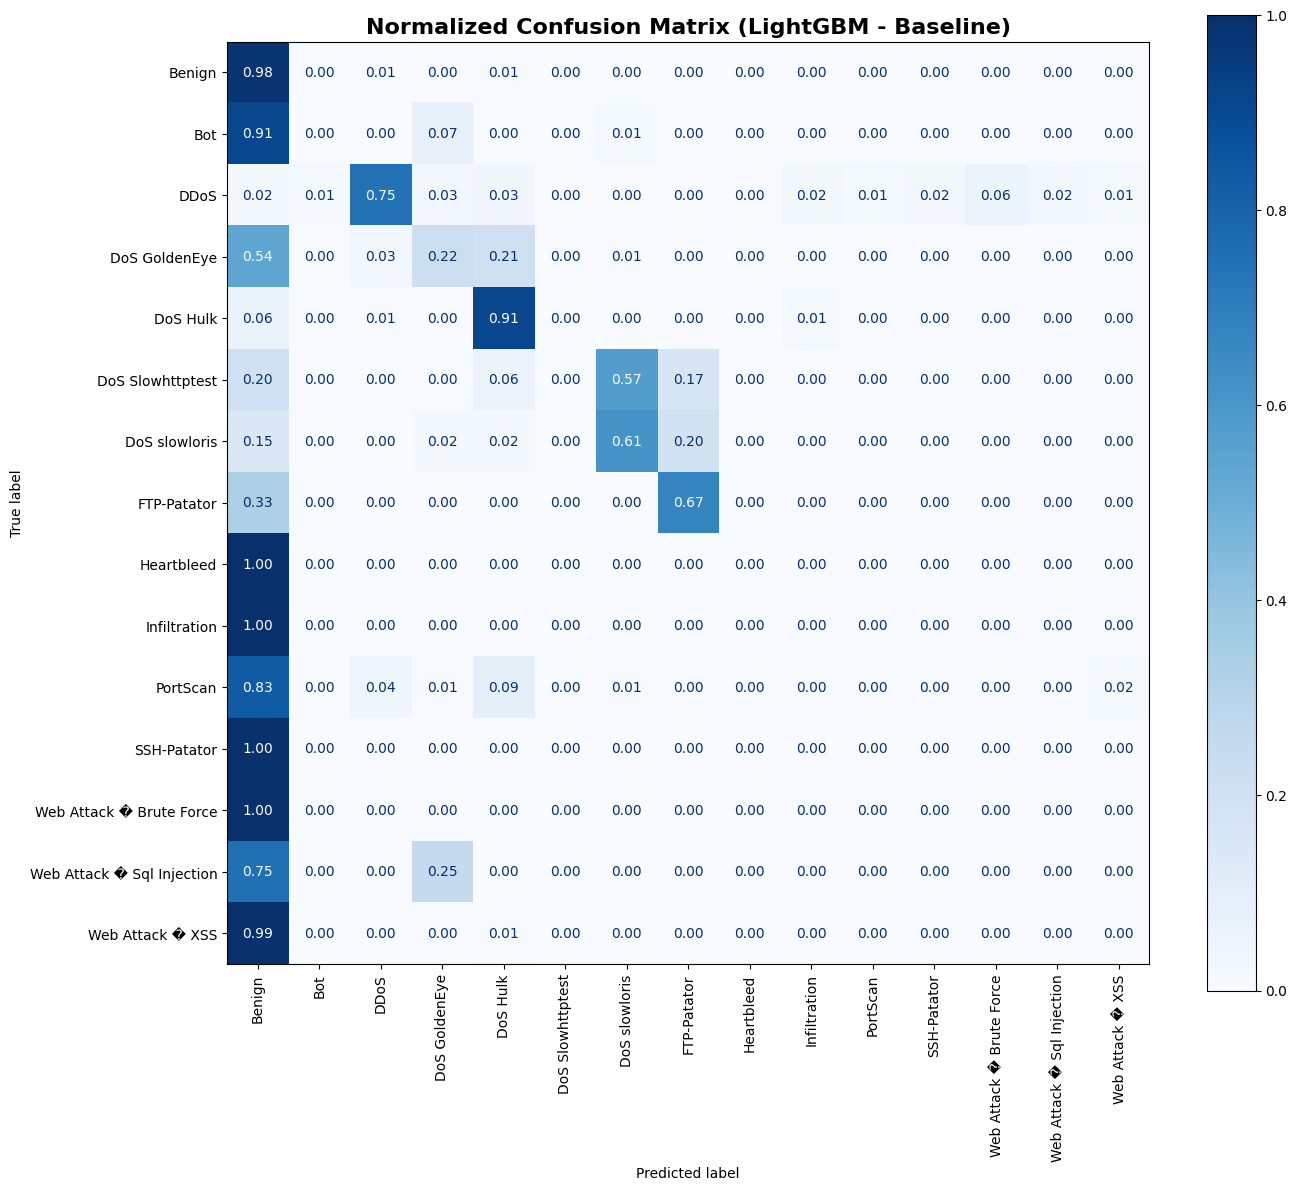

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lgbm,
    labels=classes,
    display_labels=class_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Normalized Confusion Matrix (LightGBM - Baseline)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "/kaggle/working/lgbm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [8]:
lgbm_results = pd.DataFrame({
    "Model": ["LightGBM"],
    "Accuracy": [accuracy],
    "Weighted Precision": [precision_weighted],
    "Weighted Recall": [recall_weighted],
    "Weighted F1": [f1_weighted],
    "Macro Precision": [precision_macro],
    "Macro Recall": [recall_macro],
    "Macro F1": [f1_macro],
    "MCC": [mcc],
    "AUC": [auc]
})

lgbm_results.to_csv("/kaggle/working/lgbm_results.csv", index=False)

print(lgbm_results)

      Model  Accuracy  Weighted Precision  Weighted Recall  Weighted F1  \
0  LightGBM  0.953157            0.958594         0.953157     0.955516   

   Macro Precision  Macro Recall  Macro F1       MCC       AUC  
0         0.262833      0.275689  0.267333  0.826165  0.936349  


In [9]:
lgbm_predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lgbm
})

lgbm_predictions.to_csv(
    "/kaggle/working/lgbm_predictions.csv",
    index=False
)